# Model Input — Brightness & Contrast Visualization

Shows what each model sees after preprocessing when the **input image has adjusted brightness or contrast**.
Hue and saturation are left untouched.

Each model section has two grids:
- **Brightness sweep** — contrast fixed at 1.0
- **Contrast sweep** — brightness fixed at 1.0

| Model | Input size | Normalization | Notes |
|---|---|---|---|
| **DepthAnything V2** | 518px longest-edge | ImageNet | Runs actual inference — outputs depth map |
| **SegGPT** | 448×448 (hard resize) | ImageNet | Processor only |
| **DINOv2** | 256 shortest-edge → 224×224 center-crop | ImageNet | Processor only |
| **Grounding DINO** | shortest-edge 800, longest ≤1333 | ImageNet | Processor only |
| **SAM2** | 1024×1024 | ImageNet | Processor only |
| **Qwen2.5-VL** | dynamic (multiples of 28) | CLIP | Processor only |

In [ ]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torch
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from transformers import (
    AutoImageProcessor,
    AutoModelForDepthEstimation,
    AutoProcessor,
    GroundingDinoProcessor,
    Sam2Processor,
    SegGptImageProcessor,
)

from touch_from_segmentation.touch_detection_alg.touch import compute_touch_region_v2, compute_touch_region
from touch_from_segmentation.touch_detection_alg.depth import predict_depth
from inference_script.src.seggpt import run_seggpt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from functools import partial

compute_touch_fn = partial(compute_touch_region_v2, dilation_radius=10, abs_d_threshold=0.05, local_radius=10)
predict_depth_fn = partial(predict_depth, clahe_clip=2.0)

PosixPath('/home/doterog/repos/uva/research/FOMO/touch_from_segmentation')

## Load processors (no model weights)

In [3]:
_DEPTH_ID = "depth-anything/Depth-Anything-V2-Small-hf"

depth_processor  = AutoImageProcessor.from_pretrained(_DEPTH_ID)
seggpt_processor = SegGptImageProcessor.from_pretrained("BAAI/seggpt-vit-large")
dinov2_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
gdino_processor  = GroundingDinoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
sam2_processor   = Sam2Processor.from_pretrained("facebook/sam2-hiera-small")
qwen_processor   = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")

## Load DepthAnything V2 model (~100 MB, CPU-friendly)

In [4]:
_depth_device = "cuda" if torch.cuda.is_available() else "cpu"
depth_model = AutoModelForDepthEstimation.from_pretrained(_DEPTH_ID).to(_depth_device).eval()
print(f"DepthAnything V2 loaded on {_depth_device}")

Loading weights: 100%|██████████| 287/287 [00:00<00:00, 1116.56it/s]


DepthAnything V2 loaded on cuda


## Load a sample

In [17]:
GH_MASKS = PROJECT_ROOT / "data" / "greatest_hits" / "annotations"


def resolve_hand_path(s: dict) -> Path | None:
    """Return the hand/stick mask path that exists on disk.

    Some manifests list hand_mask_path but only _stick.png files were written,
    and vice-versa. Tries both keys, then falls back to probing the image stem.
    """
    for key in ("hand_mask_path", "stick_mask_path"):
        val = s.get(key)
        if val and Path(val).exists():
            return Path(val)
    img_stem = Path(s.get("image_path", "")).stem
    folder   = Path(s.get("image_path", "")).parent
    for suffix in ("_stick.png", "_hand.png"):
        candidate = folder / (img_stem + suffix)
        if candidate.exists():
            return candidate
    return None


def _context_key(s: dict) -> str:
    """Return the grouping key used for context sampling.

    If a sample carries ``object_name`` (EPIC Kitchen), the key is the object
    name alone so context is drawn from any video containing that object type,
    maximising sample diversity.

    For datasets without ``object_name`` (Greatest Hits, Manual), each video
    contains only one object type, so ``video_id`` alone is sufficient.
    """
    raw = s.get("object_name")
    # Guard against NaN (float) from the pandas DataFrame→dict roundtrip in
    # generate_annotations.py when some entries lacked object_name.
    object_name = raw.strip() if isinstance(raw, str) else ""
    if object_name:
        return object_name
    return s.get("video_id", "")


annotations_path = GH_MASKS / "train.json"
with open(annotations_path) as f:
    annotations = json.load(f)

context_dict = GH_MASKS / "train_ctx_index.json"
with open(context_dict) as f:
    context_dict = json.load(f)

sample = None
count = 0
for s in annotations:
    hand_path = resolve_hand_path(s)
    if hand_path is not None:
        sample = s
        count += 1
        if count >= 5:  # just pick the 5th usable sample to get some variety
            ctx_key = _context_key(s)
            context_samples = context_dict.get(ctx_key, [])
            print(f"Context samples for key '{ctx_key}': {len(context_samples)} available")
            # Load context samples
            ctx_sample = annotations[context_samples[0]] if context_samples else None
            break

assert sample is not None, "No usable sample found — check GH_MASKS path"
assert ctx_sample is not None, "No context sample found for the selected key — check train_ctx_index.json"


touch_mask_key = "touch_mask_path" if "touch_mask_path" in sample else "target_path"

# Load the main sample's image and masks

img_pil  = Image.open(sample["image_path"]).convert("RGB")
img_np   = np.array(img_pil)
hand_np  = np.array(Image.open(hand_path).convert("L"))
obj_np   = np.array(Image.open(sample["object_mask_path"]).convert("L"))
touch_np = np.array(Image.open(sample[touch_mask_key]).convert("L"))

# Load the context sample's image and masks

ctx_img_pil  = Image.open(ctx_sample["image_path"]).convert("RGB")
ctx_img_np   = np.array(ctx_img_pil)
ctx_hand_np  = np.array(Image.open(resolve_hand_path(ctx_sample)).convert("L"))
ctx_obj_np   = np.array(Image.open(ctx_sample["object_mask_path"]).convert("L"))
ctx_touch_np = np.array(Image.open(ctx_sample[touch_mask_key]).convert("L"))

print(f"Image : {img_np.shape}  —  {sample['image_path']}")
print(f"Hand  : {hand_path}")
print(f"Context Image : {ctx_img_np.shape}  —  {ctx_sample['image_path']}")

Context samples for key '2015-02-16-16-49-06_denoised': 64 available
Image : (256, 456, 3)  —  /home/doterog/repos/uva/research/FOMO/touch_from_segmentation/data/greatest_hits/masks/2015-02-16-16-49-06_denoised/frame_000196.jpg
Hand  : /home/doterog/repos/uva/research/FOMO/touch_from_segmentation/data/greatest_hits/masks/2015-02-16-16-49-06_denoised/frame_000196_stick.png
Context Image : (256, 456, 3)  —  /home/doterog/repos/uva/research/FOMO/touch_from_segmentation/data/greatest_hits/masks/2015-02-16-16-49-06_denoised/frame_000080.jpg


## Helpers

In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
CLIP_MEAN     = np.array([0.48145466, 0.4578275,  0.40821073], dtype=np.float32)
CLIP_STD      = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)


def adjust_brightness(pil_img: Image.Image, factor: float) -> Image.Image:
    """factor < 1 = darker, factor > 1 = brighter, 1.0 = original."""
    return ImageEnhance.Brightness(pil_img).enhance(factor)


def adjust_contrast(pil_img: Image.Image, factor: float) -> Image.Image:
    """factor < 1 = flat/grey, factor > 1 = high contrast, 1.0 = original."""
    return ImageEnhance.Contrast(pil_img).enhance(factor)

def propagate_mask(frame_pil, prompt_pil, obj_mask_pil, hand_mask_pil):
    obj_mask = run_seggpt(frame_pil, prompt_pil, obj_mask_pil)
    hand_mask = run_seggpt(frame_pil, prompt_pil, hand_mask_pil)
    depth_map = predict_depth_fn(frame_pil)
    computed_touch = compute_touch_fn(hand_mask, obj_mask, depth_map)
    return computed_touch

def denorm(tensor_chw, mean=IMAGENET_MEAN, std=IMAGENET_STD) -> np.ndarray:
    arr = tensor_chw.numpy().transpose(1, 2, 0)
    arr = arr * std + mean
    return np.clip(arr * 255, 0, 255).astype(np.uint8)


def qwen_reconstruct(pixel_values: torch.Tensor, image_grid_thw: torch.Tensor) -> np.ndarray:
    t, h, w = image_grid_thw[0].tolist()
    C, tp, ph, pw = 3, 2, 14, 14
    pv = pixel_values.reshape(t, h, w, C, tp, ph, pw)
    pv = pv[0, :, :, :, 0, :, :]
    pv = pv.permute(2, 0, 3, 1, 4)
    pv = pv.reshape(C, int(h * ph), int(w * pw))
    return denorm(pv, mean=CLIP_MEAN, std=CLIP_STD)


# ---- per-model process functions ----

def depth_predict(pil_img: Image.Image) -> np.ndarray:
    """Run DepthAnything V2 → colorized depth map (HWC uint8, inferno colormap)."""
    inputs = depth_processor(images=pil_img, return_tensors="pt")
    inputs = {k: v.to(_depth_device) for k, v in inputs.items()}
    with torch.no_grad():
        depth_raw = depth_model(**inputs).predicted_depth
    depth = F.interpolate(
        depth_raw.unsqueeze(1),
        size=(pil_img.height, pil_img.width),
        mode="bicubic",
        align_corners=False,
    ).squeeze().cpu().numpy()
    d_min, d_max = depth.min(), depth.max()
    depth_norm = (depth - d_min) / (d_max - d_min) if d_max > d_min else np.zeros_like(depth)
    return (plt.get_cmap("inferno")(depth_norm)[:, :, :3] * 255).astype(np.uint8)


def seggpt_process(pil_img):
    inputs = seggpt_processor(images=pil_img, prompt_images=pil_img, return_tensors="pt")
    pv = inputs["pixel_values"][0]
    return pv[:, :, :]

def dinov2_process(pil_img):
    return dinov2_processor(images=pil_img, return_tensors="pt")["pixel_values"][0]

def gdino_process(pil_img):
    return gdino_processor(images=pil_img, text="object", return_tensors="pt")["pixel_values"][0]

def sam2_process(pil_img):
    return sam2_processor(images=pil_img, return_tensors="pt")["pixel_values"][0]

_qwen_messages  = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "describe"}]}]
_qwen_chat_text = qwen_processor.apply_chat_template(_qwen_messages, tokenize=False, add_generation_prompt=True)

def qwen_process(pil_img):
    inputs = qwen_processor(text=[_qwen_chat_text], images=[pil_img], return_tensors="pt")
    return inputs["pixel_values"], inputs["image_grid_thw"]


# ---- grid helpers ----

def show_jitter_grid(
    img_pil: Image.Image,
    factors: list[float],
    adjust_fn,        # adjust_brightness or adjust_contrast
    process_fn,
    model_name: str,
    sweep_name: str,  # "Brightness" or "Contrast"
    denorm_fn=None,
) -> None:
    """One row per factor: left = adjusted input, right = model output."""
    if denorm_fn is None:
        denorm_fn = denorm
    n = len(factors)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = [axes]
    for row, factor in enumerate(factors):
        adjusted = adjust_fn(img_pil, factor)
        output   = denorm_fn(process_fn(adjusted))
        label    = f"{sweep_name}={factor:.1f}" + ("  (original)" if factor == 1.0 else "")
        axes[row][0].imshow(adjusted)
        axes[row][0].set_title(f"Input — {label}")
        axes[row][0].axis("off")
        axes[row][1].imshow(output)
        axes[row][1].set_title(f"{model_name} output\n{output.shape[1]}×{output.shape[0]}px")
        axes[row][1].axis("off")
    fig.suptitle(f"{model_name} — {sweep_name} sweep", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


BRIGHTNESS_FACTORS = [0.3, 0.6, 1.0, 1.4, 1.8]   # ← edit to taste
CONTRAST_FACTORS   = [0.3, 0.6, 1.0, 1.4, 1.8]   # ← edit to taste

---
## DepthAnything V2

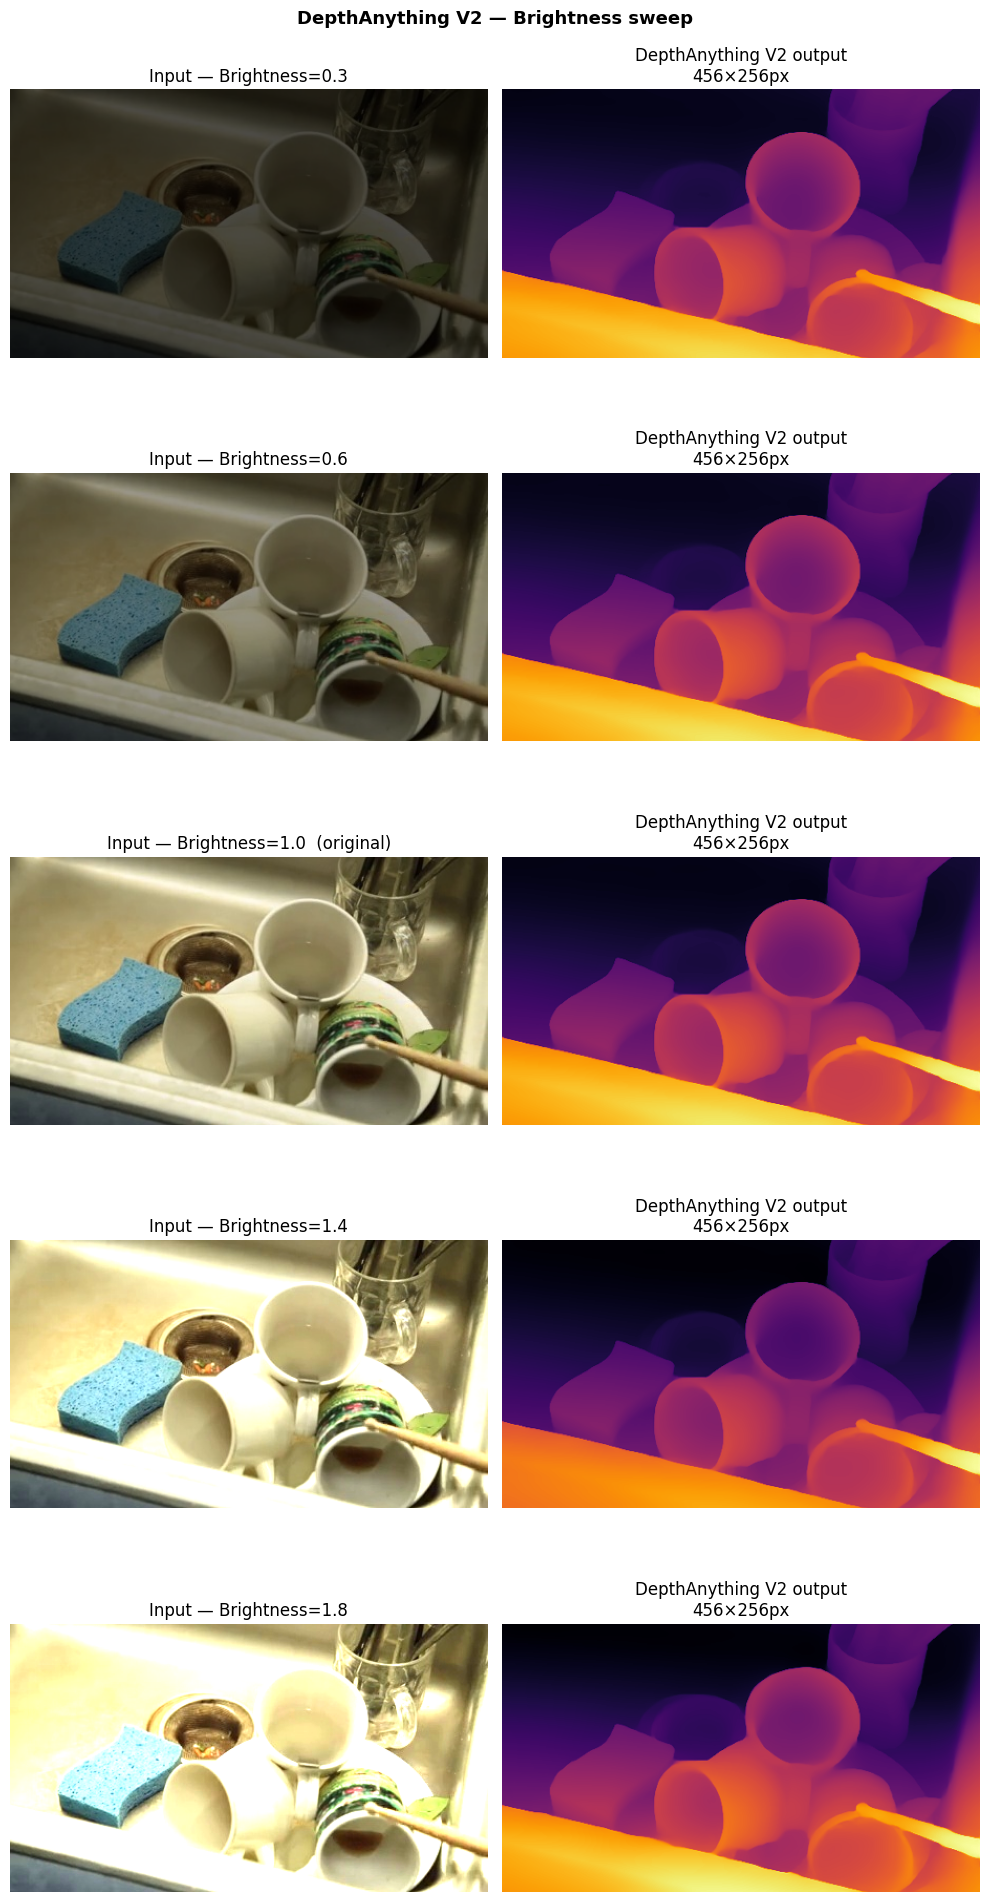

In [8]:
show_jitter_grid(img_pil, BRIGHTNESS_FACTORS, adjust_brightness,
                 depth_predict, "DepthAnything V2", "Brightness", denorm_fn=lambda x: x)

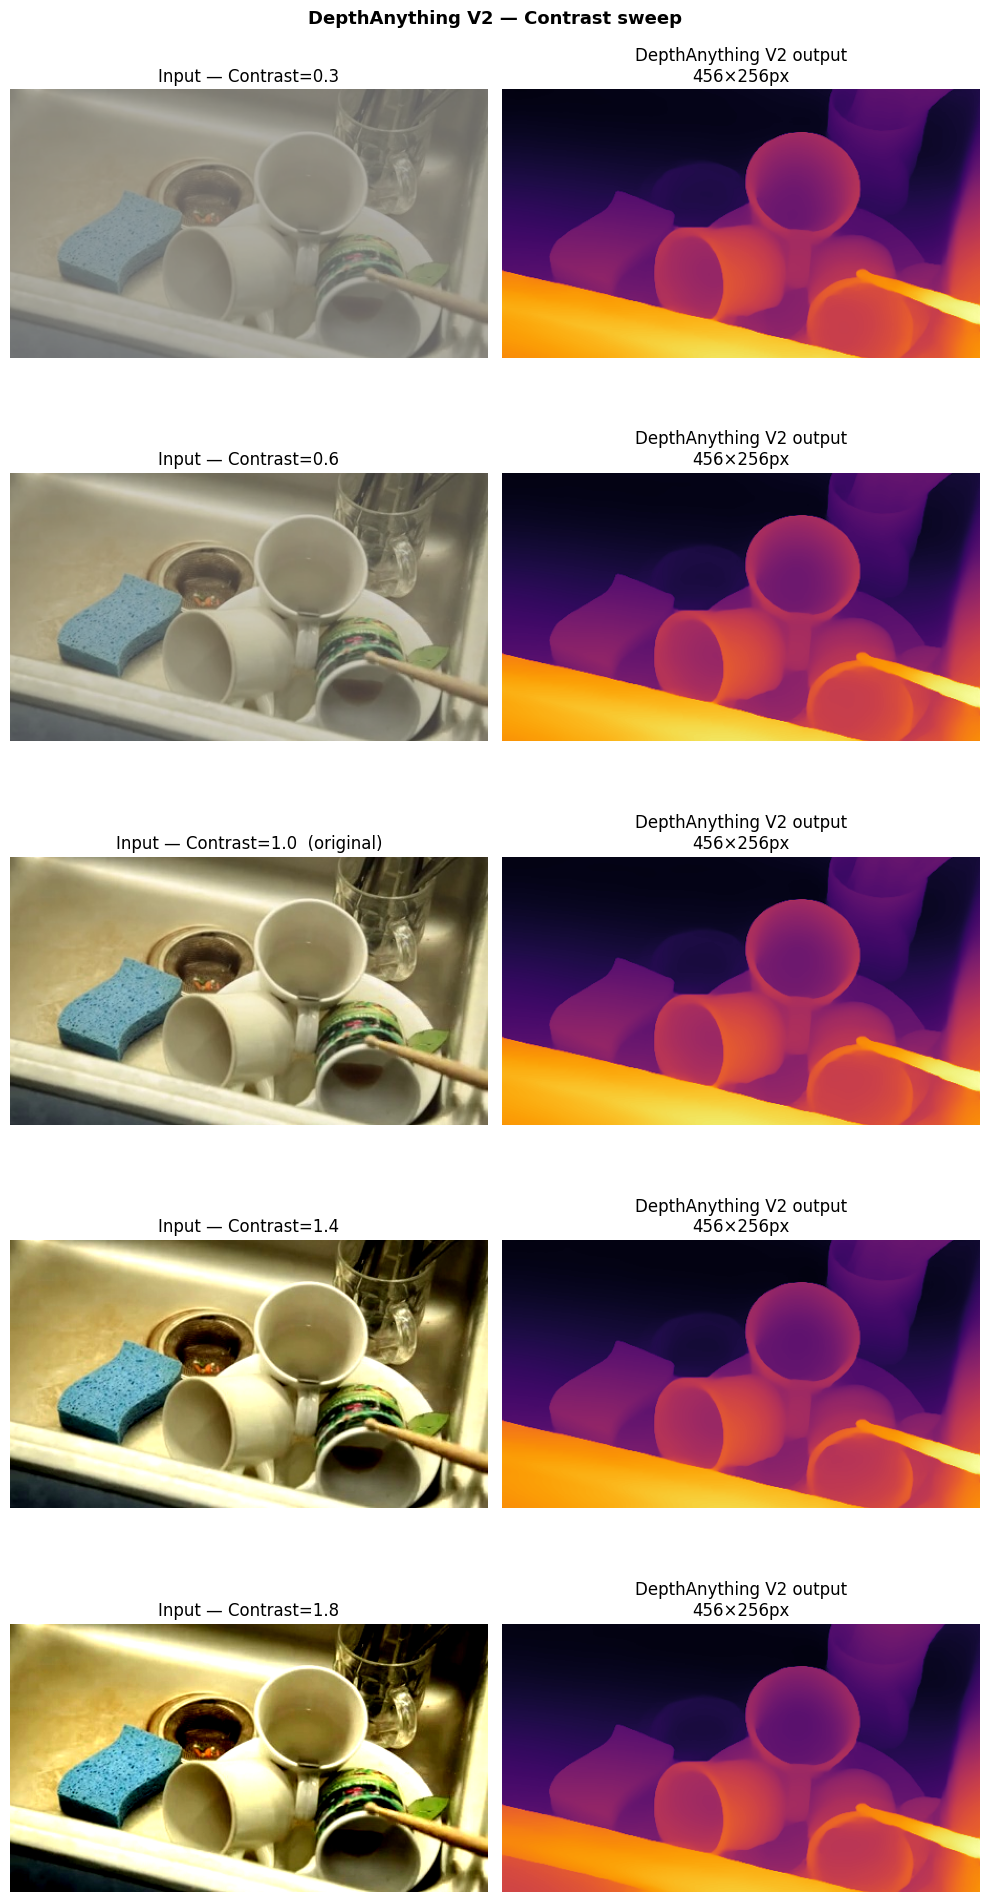

In [9]:
show_jitter_grid(img_pil, CONTRAST_FACTORS, adjust_contrast,
                 depth_predict, "DepthAnything V2", "Contrast", denorm_fn=lambda x: x)

---
## SegGPT

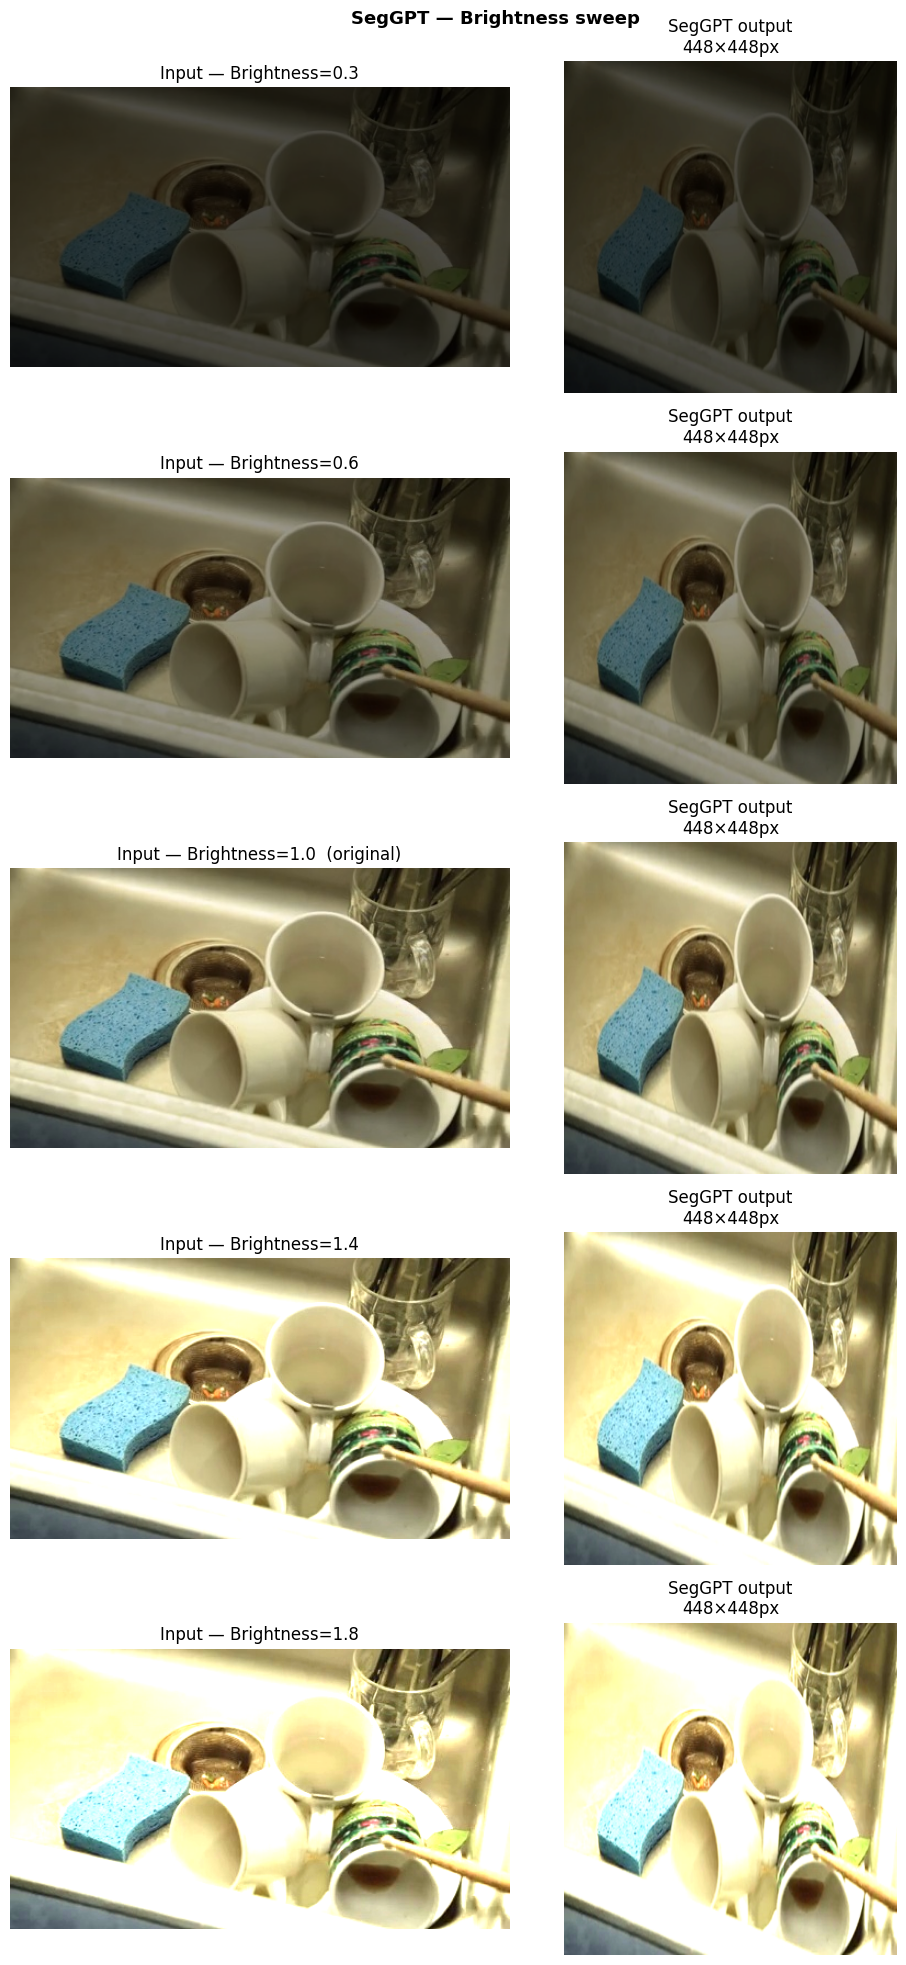

In [13]:
show_jitter_grid(img_pil, BRIGHTNESS_FACTORS, adjust_brightness, seggpt_process, "SegGPT", "Brightness")

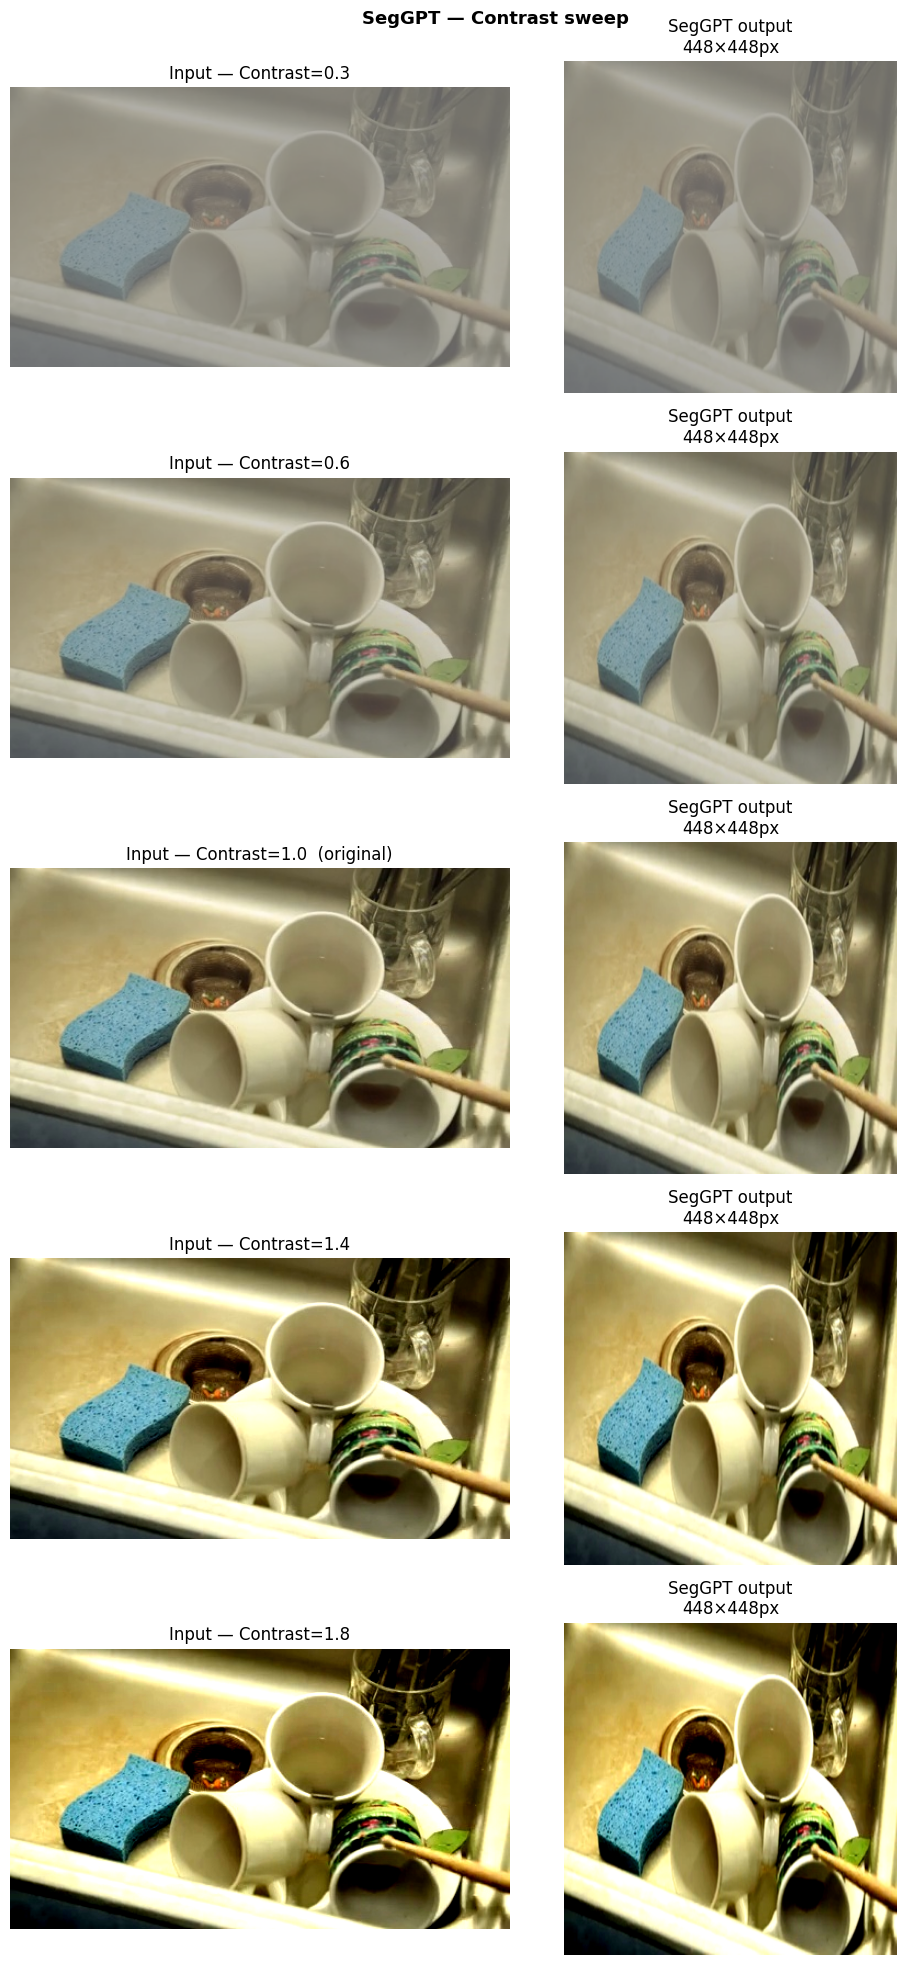

In [14]:
show_jitter_grid(img_pil, CONTRAST_FACTORS, adjust_contrast, seggpt_process, "SegGPT", "Contrast")

---
## DINOv2

In [ ]:
show_jitter_grid(img_pil, BRIGHTNESS_FACTORS, adjust_brightness, dinov2_process, "DINOv2", "Brightness")

In [ ]:
show_jitter_grid(img_pil, CONTRAST_FACTORS, adjust_contrast, dinov2_process, "DINOv2", "Contrast")

---
## Grounding DINO

In [ ]:
show_jitter_grid(img_pil, BRIGHTNESS_FACTORS, adjust_brightness, gdino_process, "Grounding DINO", "Brightness")

In [ ]:
show_jitter_grid(img_pil, CONTRAST_FACTORS, adjust_contrast, gdino_process, "Grounding DINO", "Contrast")

---
## SAM2

In [ ]:
show_jitter_grid(img_pil, BRIGHTNESS_FACTORS, adjust_brightness, sam2_process, "SAM2", "Brightness")

In [ ]:
show_jitter_grid(img_pil, CONTRAST_FACTORS, adjust_contrast, sam2_process, "SAM2", "Contrast")

---
## Qwen2.5-VL

In [ ]:
def qwen_denorm_fn(result):
    pv, grid = result
    return qwen_reconstruct(pv, grid)

show_jitter_grid(img_pil, BRIGHTNESS_FACTORS, adjust_brightness,
                 qwen_process, "Qwen2.5-VL", "Brightness", denorm_fn=qwen_denorm_fn)

In [ ]:
show_jitter_grid(img_pil, CONTRAST_FACTORS, adjust_contrast,
                 qwen_process, "Qwen2.5-VL", "Contrast", denorm_fn=qwen_denorm_fn)

---
## All models side-by-side at one brightness + contrast setting

In [ ]:
BRIGHTNESS = 0.6   # ← change this (1.0 = original)
CONTRAST   = 1.4   # ← change this (1.0 = original)

adjusted = adjust_contrast(adjust_brightness(img_pil, BRIGHTNESS), CONTRAST)

depth_out  = depth_predict(adjusted)
seggpt_out = denorm(seggpt_process(adjusted))
dinov2_out = denorm(dinov2_process(adjusted))
gdino_out  = denorm(gdino_process(adjusted))
sam2_out   = denorm(sam2_process(adjusted))
qwen_pv, qwen_grid = qwen_process(adjusted)
qwen_out   = qwen_reconstruct(qwen_pv, qwen_grid)
qt, qh, qw = qwen_grid[0].tolist()

images = [np.array(adjusted), depth_out, seggpt_out, dinov2_out, gdino_out, sam2_out, qwen_out]
titles = [
    f"Input\nbright={BRIGHTNESS} · contrast={CONTRAST}",
    f"DepthAnything V2\n{depth_out.shape[1]}×{depth_out.shape[0]}px",
    f"SegGPT\n{seggpt_out.shape[1]}×{seggpt_out.shape[0]}px",
    f"DINOv2\n{dinov2_out.shape[1]}×{dinov2_out.shape[0]}px",
    f"Grounding DINO\n{gdino_out.shape[1]}×{gdino_out.shape[0]}px",
    f"SAM2\n{sam2_out.shape[1]}×{sam2_out.shape[0]}px",
    f"Qwen2.5-VL\n{qw*14}×{qh*14}px  (grid {qh}×{qw})",
]

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle(f"All models — brightness={BRIGHTNESS}, contrast={CONTRAST}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()